# Multivariate Joint Forecasting: Remittance, Exchange Rate & Inflation (Bangladesh)
## 1. Exploratory Data Analysis (EDA)

**Goal:** Understand the trend, seasonality, distribution, stationarity, and inter-relationships
between Bangladesh's monthly **remittance inflow**, **USD/BDT exchange rate**, and **inflation rate (YoY)**
before building ML forecasting models (Linear Regression → XGBoost → LightGBM → LSTM).

**Data files used:**
- `bangladesh_monthly_remittance_2010_2026.csv` — Remittance (Million USD)
- `USD_to_BDT_Monthly_Exchange_Rates_2010_2026_3_columns.csv` — Exchange Rate
- `bangladesh_monthly_inflation_2010_2026.csv` — Inflation Rate (YoY, point-to-point)
- `bangladesh_macro_indicators_2010_2026.csv` — Combined reference file (used for cross-validation of the three series above)


### 1.1 Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


### 1.2 Load Raw Data
Loading all four CSV files as provided.

In [ ]:
remit_raw = pd.read_csv("bangladesh_monthly_remittance_2010_2026.csv")
fx_raw    = pd.read_csv("USD_to_BDT_Monthly_Exchange_Rates_2010_2026_3_columns.csv")
infl_raw  = pd.read_csv("bangladesh_monthly_inflation_2010_2026.csv")
macro_raw = pd.read_csv("bangladesh_macro_indicators_2010_2026.csv")

print("Remittance:", remit_raw.shape)
print("Exchange Rate:", fx_raw.shape)
print("Inflation:", infl_raw.shape)
print("Macro (combined):", macro_raw.shape)


Remittance: (199, 3)
Exchange Rate: (200, 3)
Inflation: (199, 3)
Macro (combined): (200, 5)


In [ ]:
remit_raw.head()

,Year,Month,Remittance (Million USD)
0,2010,January,833.55
1,2010,February,932.07
2,2010,March,1083.02
3,2010,April,1055.42
4,2010,May,796.18


In [ ]:
fx_raw.head()

,Year,Month,Exchange Rate
0,2010,January,69.12
1,2010,February,69.25
2,2010,March,69.20
3,2010,April,69.28
4,2010,May,69.35


In [ ]:
infl_raw.head()

,Year,Month,Inflation Rate (YoY Point-to-Point)
0,2010,January,8.14%
1,2010,February,8.03%
2,2010,March,8.05%
3,2010,April,8.14%
4,2010,May,8.47%


In [ ]:
macro_raw.head()

,Year,Month,Remittance (USD Millions),Inflation Rate (YoY %),USD to BDT Exchange Rate
0,2010,January,842.90,8.55,69.22
1,2010,February,849.84,8.61,69.27
2,2010,March,892.45,8.69,69.31
3,2010,April,894.03,8.63,69.33
4,2010,May,944.17,8.38,69.30


### 1.3 Data Quality Check
Check dtypes, missing values, and duplicate Year-Month rows in each file before cleaning.

In [ ]:
def quality_report(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing values:\n", df.isna().sum())
    dup = df.duplicated(subset=["Year", "Month"]).sum()
    print(f"\nDuplicate Year-Month rows: {dup}")
    print("=" * 50, "\n")

for df, name in [(remit_raw, "Remittance"), (fx_raw, "Exchange Rate"),
                  (infl_raw, "Inflation"), (macro_raw, "Macro (combined)")]:
    quality_report(df, name)


--- Remittance ---
Shape: (199, 3)

Dtypes:
 Year                          int64
Month                        object
Remittance (Million USD)    float64
dtype: object

Missing values:
 Year                        0
Month                       0
Remittance (Million USD)    0
dtype: int64

Duplicate Year-Month rows: 0

--- Exchange Rate ---
Shape: (200, 3)

Dtypes:
 Year               int64
Month             object
Exchange Rate    float64
dtype: object

Missing values:
 Year             0
Month            0
Exchange Rate    0
dtype: int64

Duplicate Year-Month rows: 0

--- Inflation ---
Shape: (199, 3)

Dtypes:
 Year                                    int64
Month                                  object
Inflation Rate (YoY Point-to-Point)    object
dtype: object

Missing values:
 Year                                   0
Month                                  0
Inflation Rate (YoY Point-to-Point)    0
dtype: int64

Duplicate Year-Month rows: 0

--- Macro (combined) ---
Shape: (200, 5)

Dt

### 1.4 Cleaning & Standardizing
- Parse `Year` + `Month` (month name) into a proper `Date` (month-start) index
- Strip `%` from the inflation column and convert to float
- Rename value columns to short, consistent names


In [ ]:
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

def add_date(df):
    df = df.copy()
    df["MonthNum"] = df["Month"].map(month_map)
    df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["MonthNum"], day=1))
    return df.sort_values("Date").reset_index(drop=True)

remit = add_date(remit_raw).rename(columns={"Remittance (Million USD)": "Remittance"})
fx    = add_date(fx_raw).rename(columns={"Exchange Rate": "ExchangeRate"})
infl  = add_date(infl_raw).rename(columns={"Inflation Rate (YoY Point-to-Point)": "Inflation"})
macro = add_date(macro_raw).rename(columns={
    "Remittance (USD Millions)": "Remittance_macro",
    "Inflation Rate (YoY %)": "Inflation_macro",
    "USD to BDT Exchange Rate": "ExchangeRate_macro"
})

# Inflation is stored as a string percentage e.g. "8.14%" -> convert to float
infl["Inflation"] = infl["Inflation"].str.rstrip("%").astype(float)

remit = remit[["Date", "Year", "MonthNum", "Remittance"]]
fx    = fx[["Date", "Year", "MonthNum", "ExchangeRate"]]
infl  = infl[["Date", "Year", "MonthNum", "Inflation"]]
macro = macro[["Date", "Year", "MonthNum", "Remittance_macro", "Inflation_macro", "ExchangeRate_macro"]]

for d in [remit, fx, infl, macro]:
    print(d["Date"].min(), "to", d["Date"].max(), "| rows:", len(d))


2010-01-01 00:00:00 to 2026-07-01 00:00:00 | rows: 199
2010-01-01 00:00:00 to 2026-08-01 00:00:00 | rows: 200
2010-01-01 00:00:00 to 2026-07-01 00:00:00 | rows: 199
2010-01-01 00:00:00 to 2026-08-01 00:00:00 | rows: 200


### 1.5 Cross-Validating the Standalone Files Against the Combined `macro` File
The project has three standalone series files *and* one combined file covering the same variables.
Before merging, check whether they agree — discrepancies matter for deciding which source to trust
for modeling.

In [ ]:
check = remit.merge(macro[["Date", "Remittance_macro"]], on="Date", how="inner")
check["diff"] = check["Remittance"] - check["Remittance_macro"]
check["pct_diff"] = (check["diff"] / check["Remittance_macro"] * 100).round(2)
print("Remittance vs macro file — summary of differences:")
print(check["diff"].describe())
check.sort_values("diff", key=abs, ascending=False).head(10)


Remittance vs macro file — summary of differences:
count     199.000000
mean       33.292261
std       266.158402
min      -888.640000
25%      -111.140000
50%        -0.290000
75%       112.180000
max      1120.270000
Name: diff, dtype: float64


,Date,Year,MonthNum,Remittance,Remittance_macro,diff,pct_diff
182,2025-03-01,2025,3,3295.63,2175.36,1120.27,51.50
191,2025-12-01,2025,12,3223.67,2183.09,1040.58,47.67
192,2026-01-01,2026,1,3171.63,2229.19,942.44,42.28
138,2021-07-01,2021,7,1709.57,2598.21,-888.64,-34.20
195,2026-04-01,2026,4,3127.30,2321.68,805.62,34.70
193,2026-02-01,2026,2,3019.45,2234.16,785.29,35.15
196,2026-05-01,2026,5,3442.58,2674.55,768.03,28.72
170,2024-03-01,2024,3,2738.93,2039.15,699.78,34.32
190,2025-11-01,2025,11,2889.73,2193.36,696.37,31.75
179,2024-12-01,2024,12,2638.78,2001.25,637.53,31.86


In [ ]:
check_fx = fx.merge(macro[["Date", "ExchangeRate_macro"]], on="Date", how="inner")
check_fx["diff"] = check_fx["ExchangeRate"] - check_fx["ExchangeRate_macro"]
print("Exchange Rate vs macro file — summary of differences:")
print(check_fx["diff"].describe())


Exchange Rate vs macro file — summary of differences:
count    200.000000
mean      -0.301800
std        2.092106
min       -8.120000
25%       -0.522500
50%       -0.155000
75%        0.100000
max        7.120000
Name: diff, dtype: float64


In [ ]:
check_infl = infl.merge(macro[["Date", "Inflation_macro"]], on="Date", how="inner")
check_infl["diff"] = check_infl["Inflation"] - check_infl["Inflation_macro"]
print("Inflation vs macro file — summary of differences:")
print(check_infl["diff"].describe())


Inflation vs macro file — summary of differences:
count    199.000000
mean      -0.172161
std        0.692181
min       -2.330000
25%       -0.410000
50%       -0.050000
75%        0.210000
max        1.110000
Name: diff, dtype: float64


> **Note:** Any systematic offset between the standalone files and the combined macro file is flagged
> above. Depending on the size of the discrepancy, decide in the modeling notebook whether to:
> (a) trust the standalone files (likely more granular/updated source), or
> (b) trust the combined macro file (likely a single consistent snapshot).
> For this EDA we proceed with the **standalone files** since they are the primary series named in the
> project scope, and keep `macro` only as a cross-check reference.

### 1.6 Build the Master Merged Dataset

In [ ]:
df = remit.merge(fx, on=["Date", "Year", "MonthNum"], how="outer") \
          .merge(infl, on=["Date", "Year", "MonthNum"], how="outer") \
          .sort_values("Date").reset_index(drop=True)

df["MonthName"] = df["Date"].dt.strftime("%B")

print("Master dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.isna().sum()


Master dataset shape: (200, 7)
Date range: 2010-01-01 to 2026-08-01


,0
Date,0
Year,0
MonthNum,0
Remittance,1
ExchangeRate,0
Inflation,1
MonthName,0


In [ ]:
df.tail(10)

,Date,Year,MonthNum,Remittance,ExchangeRate,Inflation,MonthName
190,2025-11-01,2025,11,2889.73,121.10,10.25,November
191,2025-12-01,2025,12,3223.67,121.40,10.08,December
192,2026-01-01,2026,1,3171.63,121.50,9.94,January
193,2026-02-01,2026,2,3019.45,121.65,9.60,February
194,2026-03-01,2026,3,3752.21,122.15,8.60,March
195,2026-04-01,2026,4,3127.30,122.20,9.04,April
196,2026-05-01,2026,5,3442.58,122.25,9.42,May
197,2026-06-01,2026,6,2819.03,122.30,9.16,June
198,2026-07-01,2026,7,2858.68,122.35,8.32,July
199,2026-08-01,2026,8,NaN,122.37,NaN,August


In [ ]:
# Rows with any missing value (misaligned coverage between the 3 source files)
df[df.isna().any(axis=1)]


,Date,Year,MonthNum,Remittance,ExchangeRate,Inflation,MonthName
199,2026-08-01,2026,8,NaN,122.37,NaN,August


### 1.7 Descriptive Statistics

In [ ]:
df[["Remittance", "ExchangeRate", "Inflation"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Remittance,199.0,1560.742111,603.550863,773.02,1112.670,1359.02,1836.2150,3752.21
ExchangeRate,200.0,88.490400,15.866186,69.12,77.800,83.19,93.0375,122.37
Inflation,199.0,7.244020,1.881837,5.11,5.755,6.46,8.8750,11.68


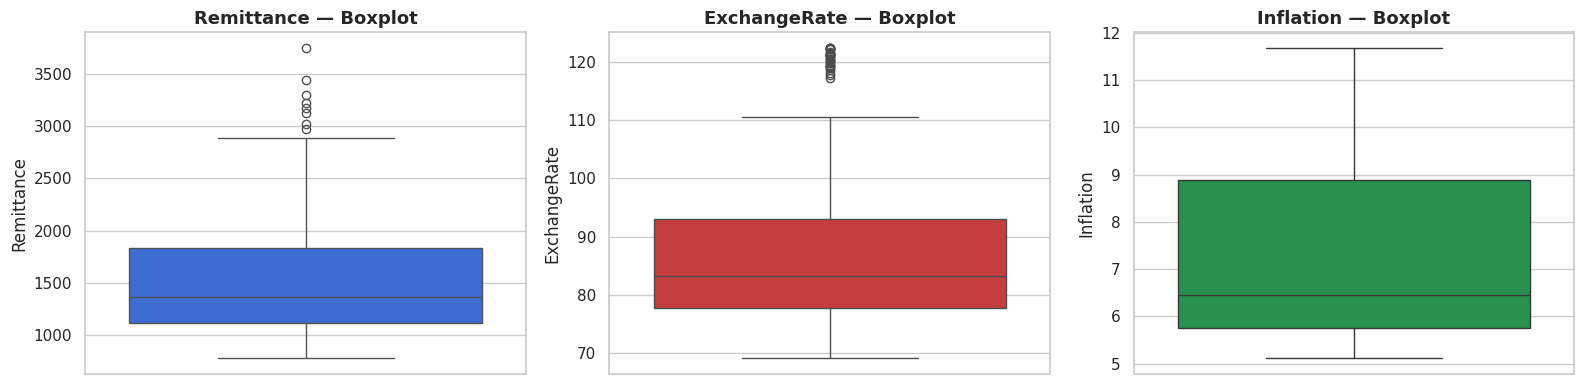

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ["Remittance", "ExchangeRate", "Inflation"],
                           ["#2563eb", "#dc2626", "#16a34a"]):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f"{col} — Boxplot")
plt.tight_layout()
plt.show()


## 2. Univariate Trend Analysis

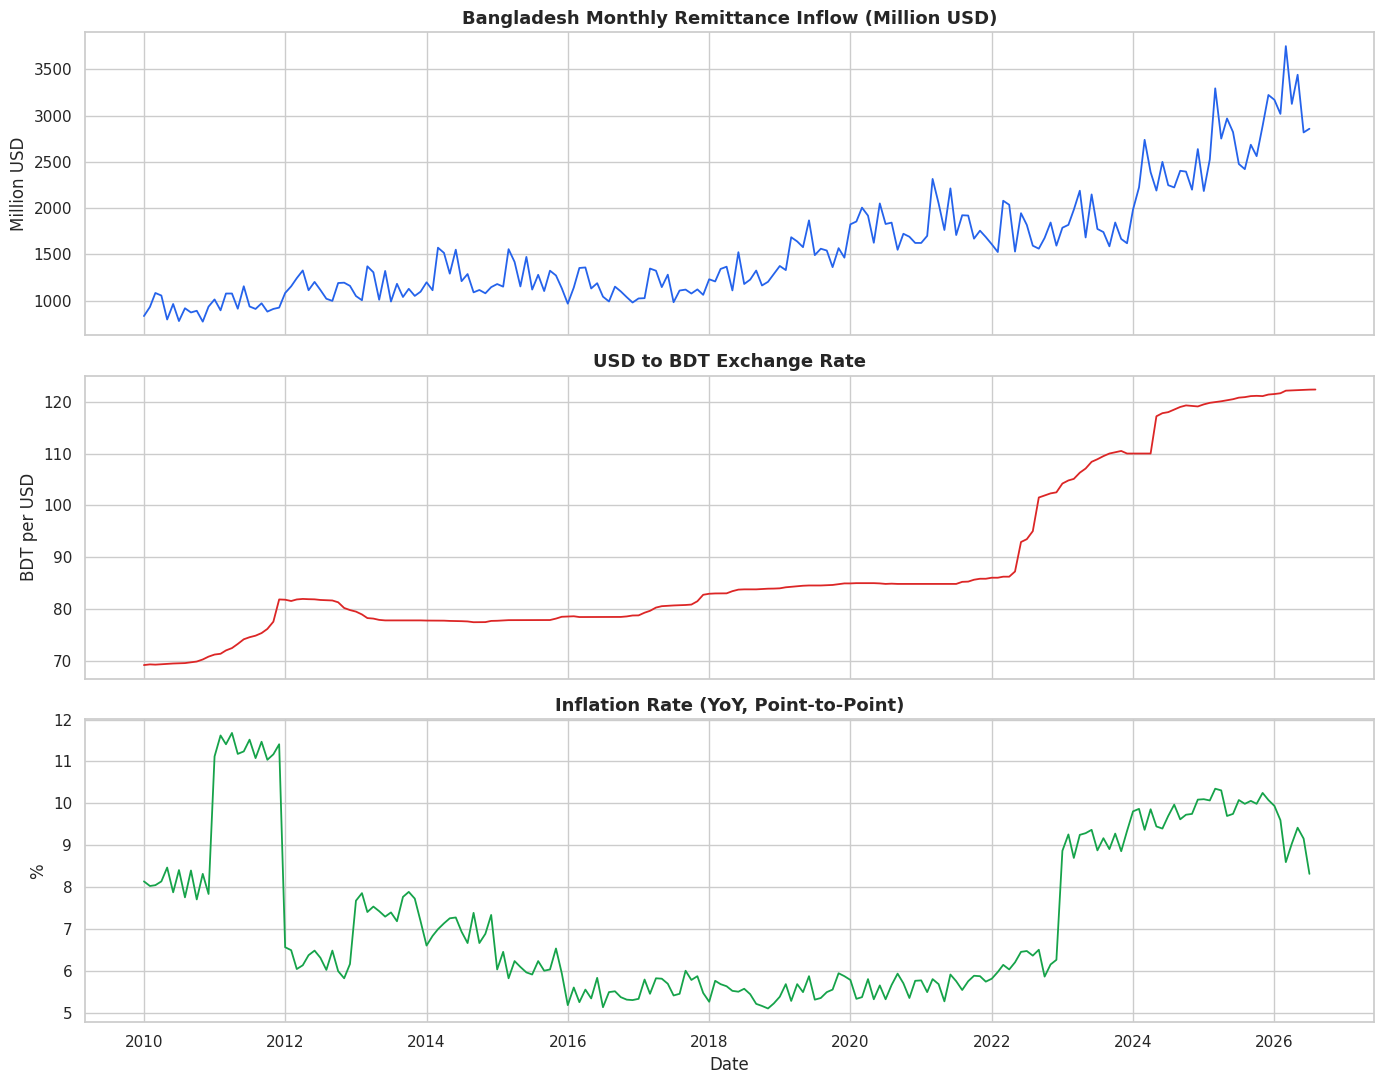

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(df["Date"], df["Remittance"], color="#2563eb", linewidth=1.3)
axes[0].set_title("Bangladesh Monthly Remittance Inflow (Million USD)")
axes[0].set_ylabel("Million USD")

axes[1].plot(df["Date"], df["ExchangeRate"], color="#dc2626", linewidth=1.3)
axes[1].set_title("USD to BDT Exchange Rate")
axes[1].set_ylabel("BDT per USD")

axes[2].plot(df["Date"], df["Inflation"], color="#16a34a", linewidth=1.3)
axes[2].set_title("Inflation Rate (YoY, Point-to-Point)")
axes[2].set_ylabel("%")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


### 2.1 Normalized Comparison (Same Axis)
Rescaling all three series to a common 0–1 range makes it easier to visually compare *when* each
series moved, independent of their different units/scales.

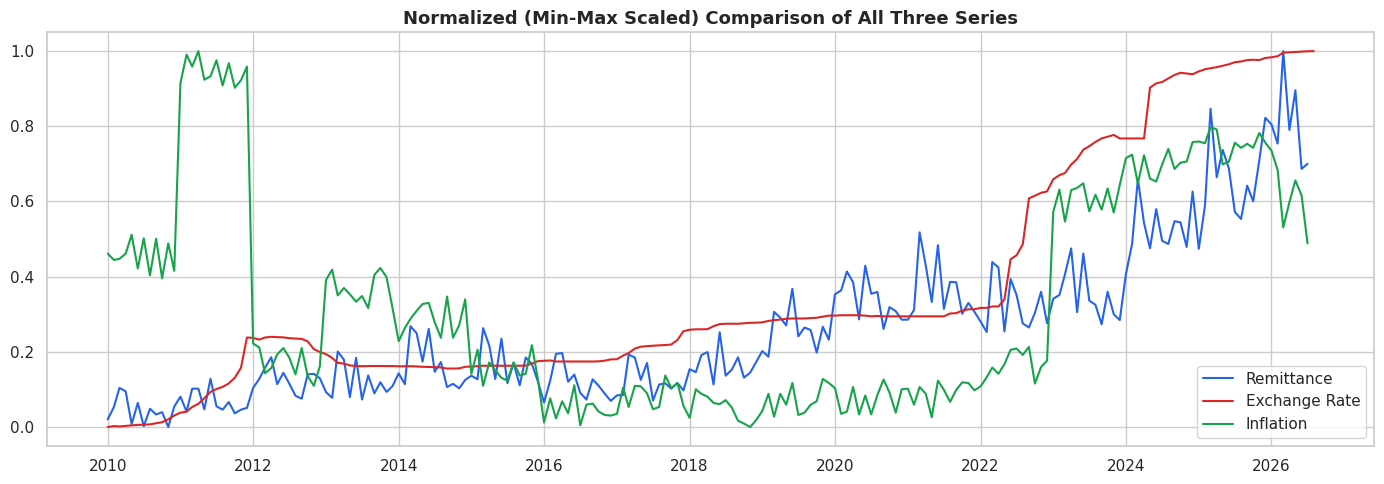

In [ ]:
norm = df.set_index("Date")[["Remittance", "ExchangeRate", "Inflation"]].copy()
norm = (norm - norm.min()) / (norm.max() - norm.min())

plt.figure(figsize=(14, 5))
plt.plot(norm.index, norm["Remittance"], label="Remittance", color="#2563eb")
plt.plot(norm.index, norm["ExchangeRate"], label="Exchange Rate", color="#dc2626")
plt.plot(norm.index, norm["Inflation"], label="Inflation", color="#16a34a")
plt.title("Normalized (Min-Max Scaled) Comparison of All Three Series")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Seasonality Analysis
Remittance inflows to Bangladesh are known to spike around **Eid-ul-Fitr** and **Eid-ul-Adha** as
migrant workers send extra money home for the holidays. Since Eid follows the lunar Islamic calendar,
its Gregorian month shifts every year — so we look at month-of-year distributions across all years
rather than assuming a fixed month.

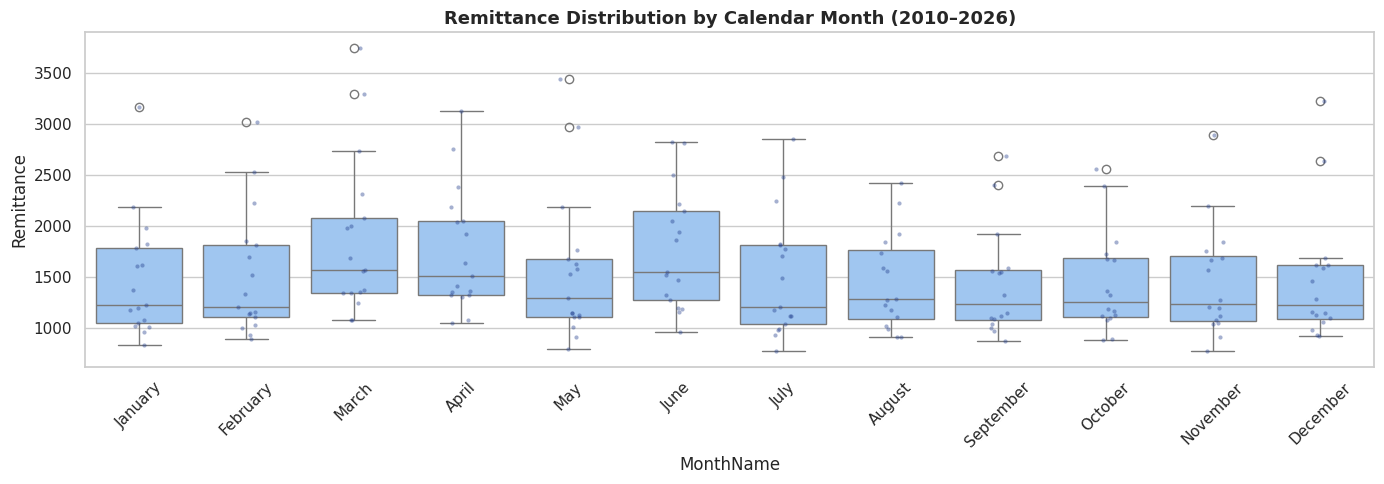

In [ ]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="MonthName", y="Remittance", order=month_order, color="#93c5fd")
sns.stripplot(data=df, x="MonthName", y="Remittance", order=month_order,
              color="#1e3a8a", alpha=0.4, size=3)
plt.title("Remittance Distribution by Calendar Month (2010–2026)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


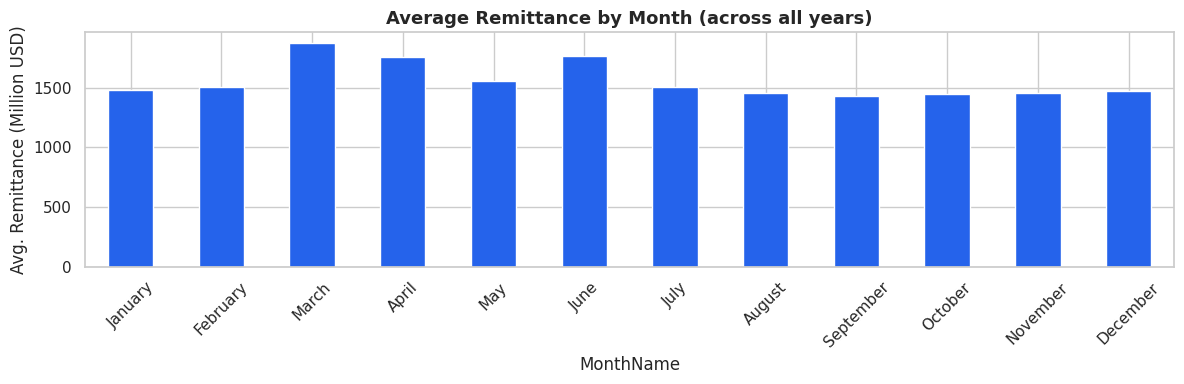

MonthName
March        1870.794706
June         1766.437059
April        1756.243529
May          1555.924706
February     1507.663529
July         1504.100588
January      1478.967647
December     1473.833750
November     1453.750625
August       1452.201250
October      1444.205000
September    1432.599375
Name: Remittance, dtype: float64


In [ ]:
monthly_avg = df.groupby("MonthName")["Remittance"].mean().reindex(month_order)
monthly_avg.plot(kind="bar", figsize=(12, 4), color="#2563eb")
plt.title("Average Remittance by Month (across all years)")
plt.ylabel("Avg. Remittance (Million USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(monthly_avg.sort_values(ascending=False))


### 3.1 Year-over-Year Growth Rates
Percentage change vs. the same month last year — removes seasonal effects and highlights the
underlying trend/growth momentum, and also lets us compare growth dynamics across the three series.

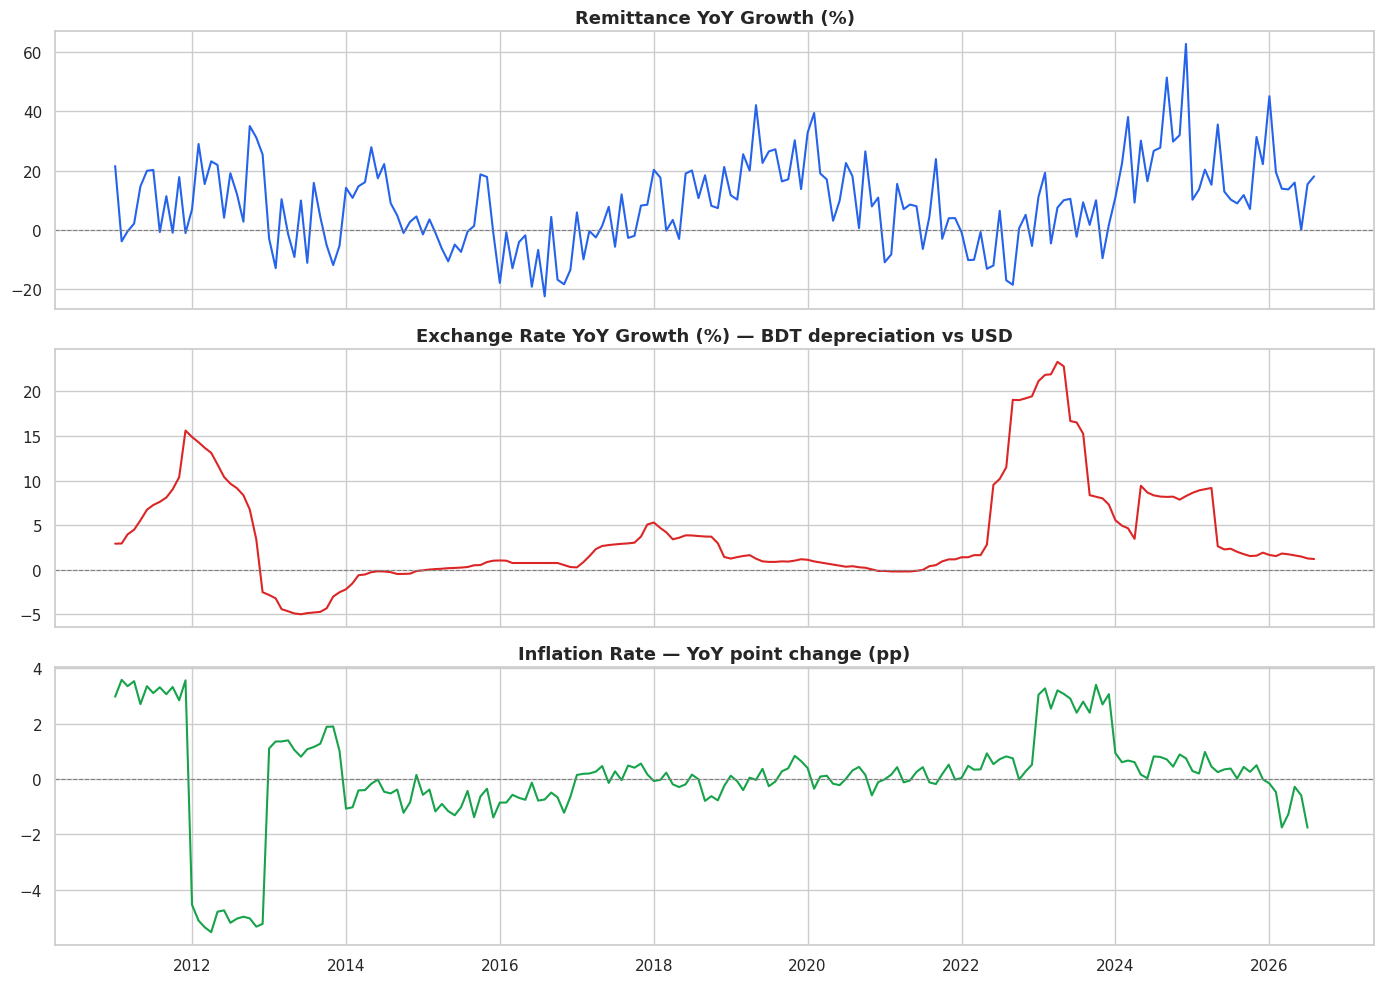

In [ ]:
df = df.sort_values("Date").reset_index(drop=True)
df["Remittance_YoY%"]   = df["Remittance"].pct_change(12) * 100
df["ExchangeRate_YoY%"] = df["ExchangeRate"].pct_change(12) * 100
df["Inflation_Diff_YoY"] = df["Inflation"].diff(12)  # inflation already a YoY %, so use point diff

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df["Date"], df["Remittance_YoY%"], color="#2563eb")
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_title("Remittance YoY Growth (%)")

axes[1].plot(df["Date"], df["ExchangeRate_YoY%"], color="#dc2626")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_title("Exchange Rate YoY Growth (%) — BDT depreciation vs USD")

axes[2].plot(df["Date"], df["Inflation_Diff_YoY"], color="#16a34a")
axes[2].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[2].set_title("Inflation Rate — YoY point change (pp)")

plt.tight_layout()
plt.show()


## 4. Seasonal Decomposition
Decompose the remittance series into **trend**, **seasonal**, and **residual** components
(multiplicative model, 12-month period) to formally confirm the seasonality observed above.

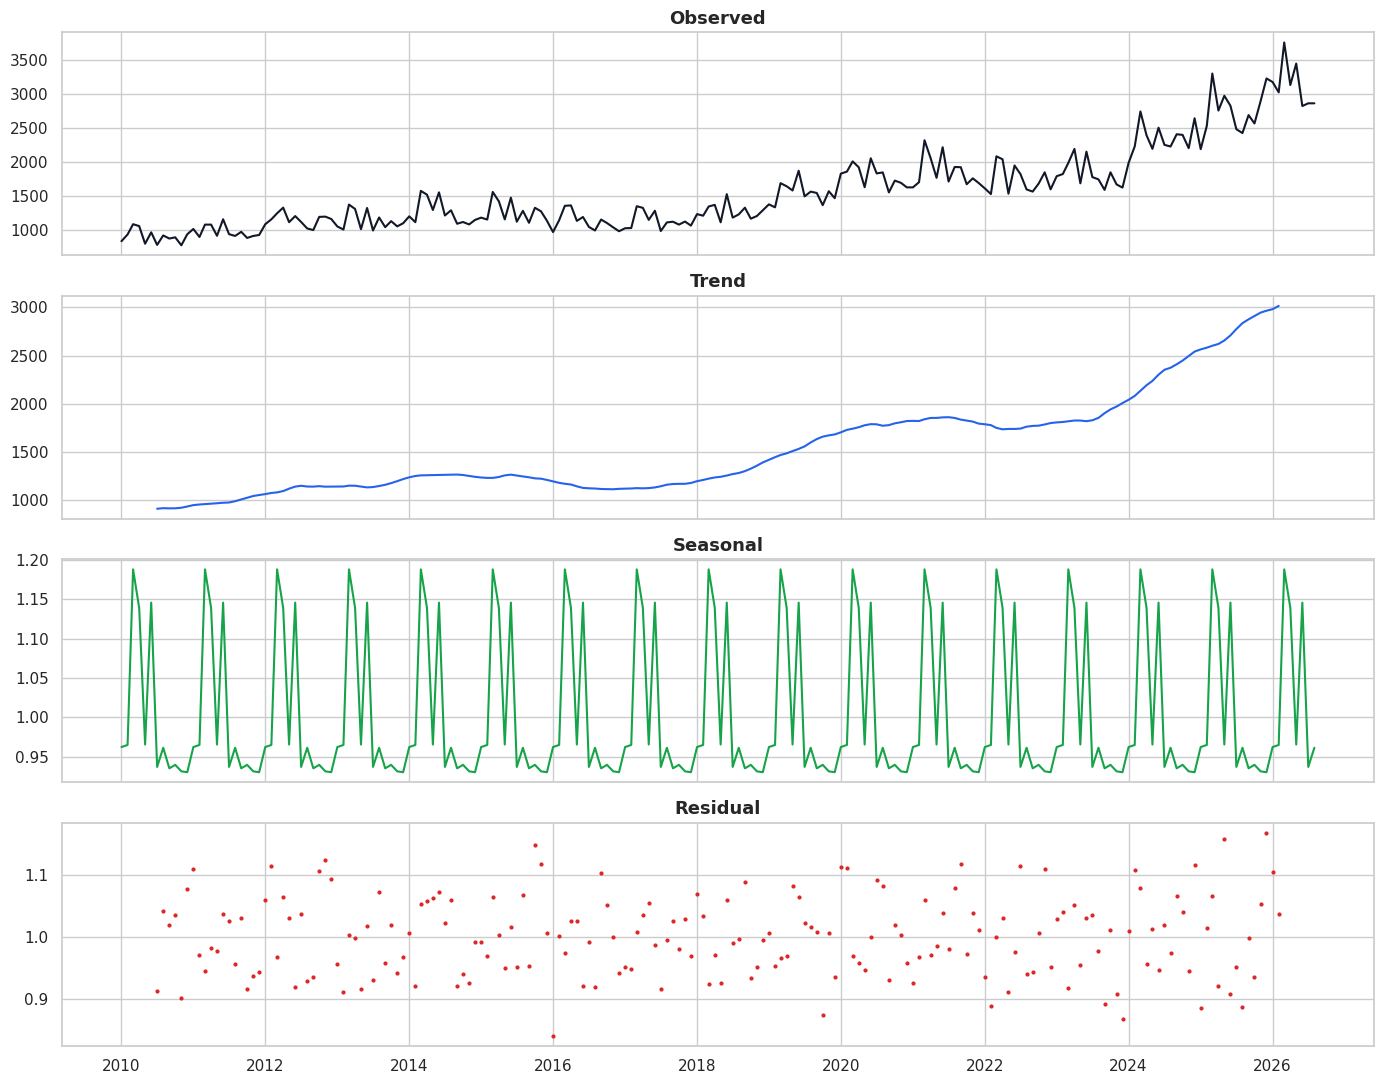

In [ ]:
ts = df.set_index("Date")["Remittance"].asfreq("MS").interpolate()

decomp = seasonal_decompose(ts, model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
axes[0].plot(decomp.observed, color="#111827"); axes[0].set_title("Observed")
axes[1].plot(decomp.trend, color="#2563eb"); axes[1].set_title("Trend")
axes[2].plot(decomp.seasonal, color="#16a34a"); axes[2].set_title("Seasonal")
axes[3].plot(decomp.resid, color="#dc2626", marker="o", linestyle="none", markersize=2); axes[3].set_title("Residual")
plt.tight_layout()
plt.show()


## 5. Stationarity Testing
ML models don't strictly require stationarity, but it's essential diagnostic info — it tells us
whether we should engineer differenced/pct-change features, and it matters a lot if we later add a
VAR-style baseline. We use both **ADF** (null = non-stationary) and **KPSS** (null = stationary).

In [ ]:
def stationarity_tests(series, name):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")

    print(f"--- {name} ---")
    print(f"ADF  statistic: {adf_stat:.4f}   p-value: {adf_p:.4f}  -> "
          f"{'Stationary' if adf_p < 0.05 else 'Non-stationary'} (ADF)")
    print(f"KPSS statistic: {kpss_stat:.4f}   p-value: {kpss_p:.4f}  -> "
          f"{'Non-stationary' if kpss_p < 0.05 else 'Stationary'} (KPSS)")
    print()

for col in ["Remittance", "ExchangeRate", "Inflation"]:
    stationarity_tests(df[col], col)


--- Remittance ---
ADF  statistic: 1.3039   p-value: 0.9966  -> Non-stationary (ADF)
KPSS statistic: 1.7290   p-value: 0.0100  -> Non-stationary (KPSS)

--- ExchangeRate ---
ADF  statistic: 0.3382   p-value: 0.9790  -> Non-stationary (ADF)
KPSS statistic: 1.6597   p-value: 0.0100  -> Non-stationary (KPSS)

--- Inflation ---
ADF  statistic: -1.7660   p-value: 0.3975  -> Non-stationary (ADF)
KPSS statistic: 0.4415   p-value: 0.0593  -> Stationary (KPSS)



In [ ]:
# First-differenced versions, for comparison
print("### After first differencing ###\n")
for col in ["Remittance", "ExchangeRate", "Inflation"]:
    stationarity_tests(df[col].diff(), f"{col} (1st diff)")


### After first differencing ###

--- Remittance (1st diff) ---
ADF  statistic: -2.9396   p-value: 0.0409  -> Stationary (ADF)
KPSS statistic: 0.0401   p-value: 0.1000  -> Stationary (KPSS)

--- ExchangeRate (1st diff) ---
ADF  statistic: -5.3240   p-value: 0.0000  -> Stationary (ADF)
KPSS statistic: 0.3435   p-value: 0.1000  -> Stationary (KPSS)

--- Inflation (1st diff) ---
ADF  statistic: -6.3836   p-value: 0.0000  -> Stationary (ADF)
KPSS statistic: 0.0813   p-value: 0.1000  -> Stationary (KPSS)



## 6. Relationship Between Variables
### 6.1 Correlation Matrix

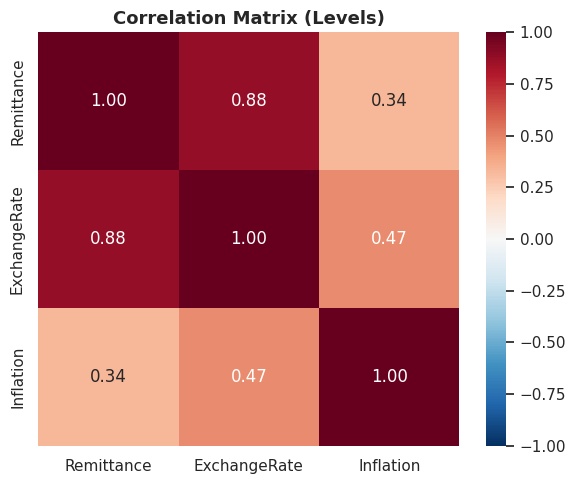

,Remittance,ExchangeRate,Inflation
Remittance,1.000000,0.880519,0.335061
ExchangeRate,0.880519,1.000000,0.470750
Inflation,0.335061,0.470750,1.000000


In [ ]:
corr = df[["Remittance", "ExchangeRate", "Inflation"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Levels)")
plt.tight_layout()
plt.show()
corr


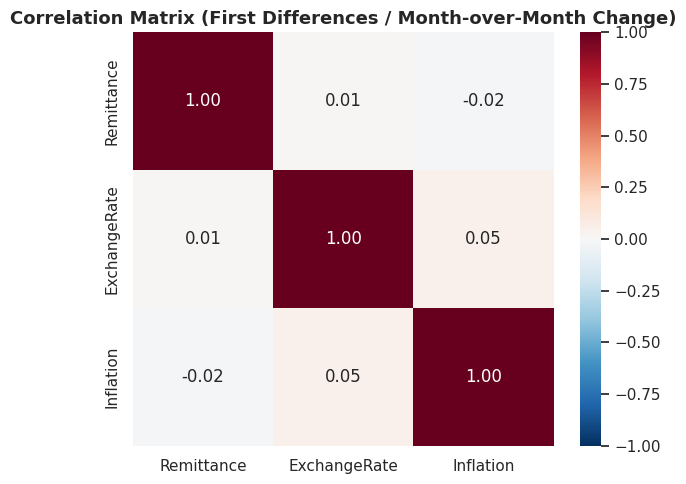

,Remittance,ExchangeRate,Inflation
Remittance,1.000000,0.014662,-0.023317
ExchangeRate,0.014662,1.000000,0.053044
Inflation,-0.023317,0.053044,1.000000


In [ ]:
# Correlation on YoY / differenced series (removes trend, often more meaningful for macro data)
diff_corr = df[["Remittance", "ExchangeRate", "Inflation"]].diff().corr()
plt.figure(figsize=(6, 5))
sns.heatmap(diff_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (First Differences / Month-over-Month Change)")
plt.tight_layout()
plt.show()
diff_corr


### 6.2 Scatter Plots — Remittance vs. Exchange Rate & Inflation

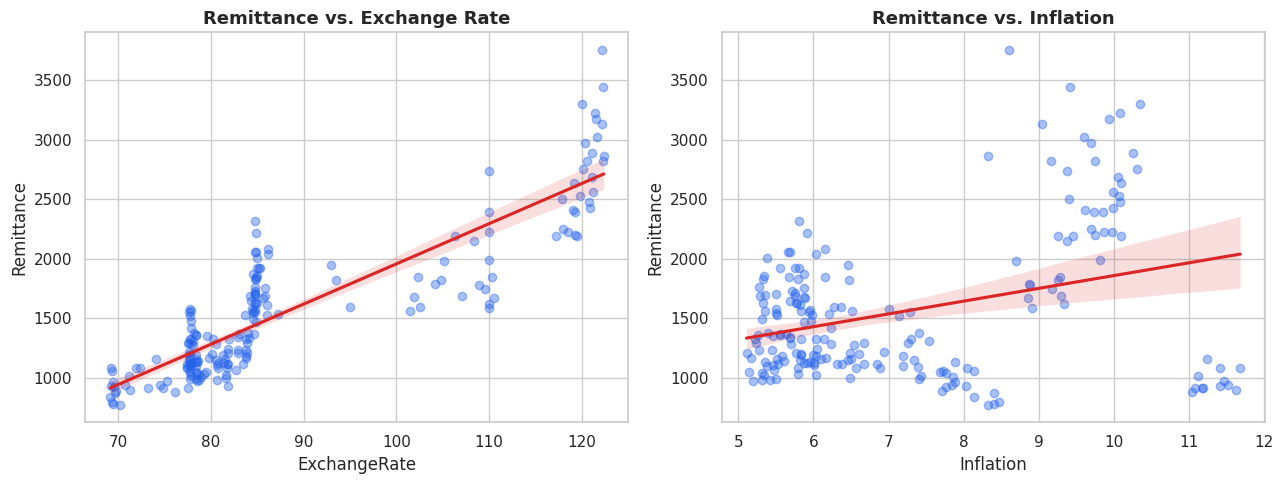

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=df, x="ExchangeRate", y="Remittance", ax=axes[0],
            scatter_kws={"alpha": 0.4, "color": "#2563eb"}, line_kws={"color": "#dc2626"})
axes[0].set_title("Remittance vs. Exchange Rate")

sns.regplot(data=df, x="Inflation", y="Remittance", ax=axes[1],
            scatter_kws={"alpha": 0.4, "color": "#2563eb"}, line_kws={"color": "#dc2626"})
axes[1].set_title("Remittance vs. Inflation")
plt.tight_layout()
plt.show()


### 6.3 Lagged Cross-Correlation
Does exchange rate or inflation lead remittance by a few months (e.g., workers responding to a
favorable exchange rate with a delay)? We check correlation between remittance and *lagged* values
of exchange rate / inflation.

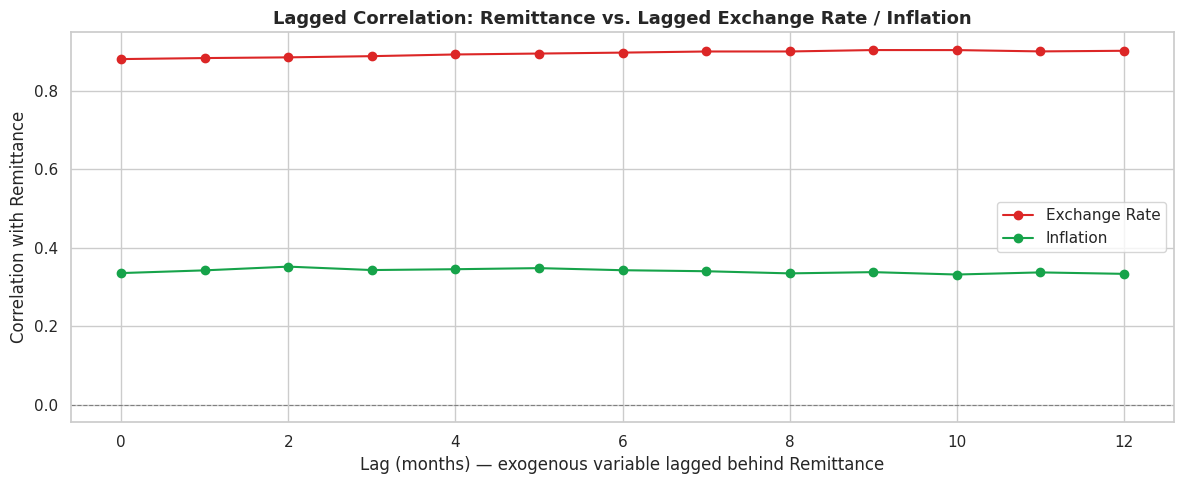

,lag,corr_with_ExchangeRate,corr_with_Inflation
0,0,0.880519,0.335061
1,1,0.883106,0.341990
2,2,0.884905,0.351491
3,3,0.887962,0.342767
4,4,0.892272,0.344891
5,5,0.894618,0.347667
6,6,0.896991,0.342337
7,7,0.899858,0.339762
8,8,0.899921,0.334291
9,9,0.903516,0.337459


In [ ]:
max_lag = 12
lag_results = {"lag": [], "corr_with_ExchangeRate": [], "corr_with_Inflation": []}

for lag in range(0, max_lag + 1):
    lag_results["lag"].append(lag)
    lag_results["corr_with_ExchangeRate"].append(df["Remittance"].corr(df["ExchangeRate"].shift(lag)))
    lag_results["corr_with_Inflation"].append(df["Remittance"].corr(df["Inflation"].shift(lag)))

lag_df = pd.DataFrame(lag_results)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lag_df["lag"], lag_df["corr_with_ExchangeRate"], marker="o", label="Exchange Rate", color="#dc2626")
ax.plot(lag_df["lag"], lag_df["corr_with_Inflation"], marker="o", label="Inflation", color="#16a34a")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Lag (months) — exogenous variable lagged behind Remittance")
ax.set_ylabel("Correlation with Remittance")
ax.set_title("Lagged Correlation: Remittance vs. Lagged Exchange Rate / Inflation")
ax.legend()
plt.tight_layout()
plt.show()
lag_df


## 7. Autocorrelation of Remittance (for feature engineering)
ACF/PACF plots help decide which lag features (e.g., t-1, t-3, t-12) are worth engineering for the
ML models in the next notebook.

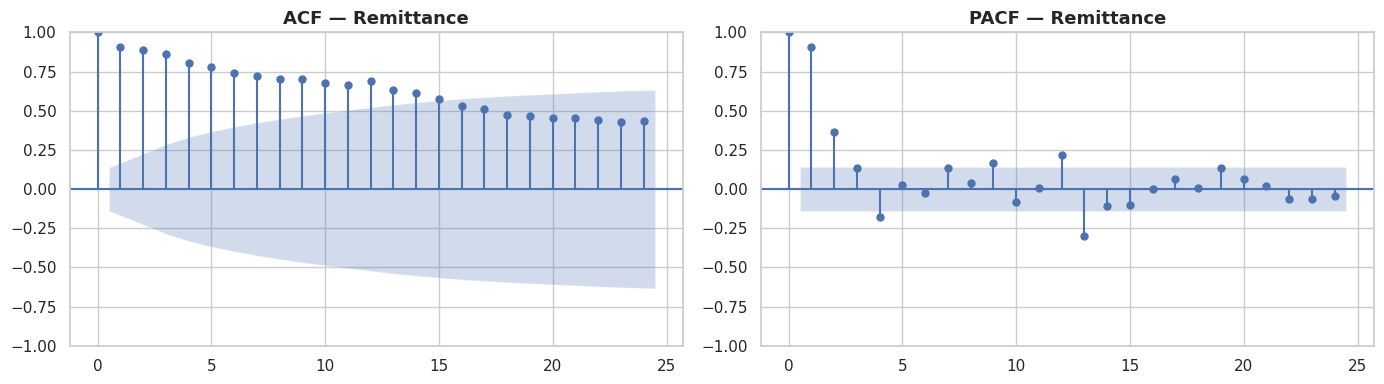

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=24, ax=axes[0])
axes[0].set_title("ACF — Remittance")
plot_pacf(ts, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Remittance")
plt.tight_layout()
plt.show()


## 8. Outlier / Anomaly Check
Flag months where remittance deviates sharply (>2 std) from its rolling mean — useful to know
whether these are genuine Eid spikes / policy-driven jumps (e.g., incentive changes, COVID-19 period)
or data issues.

In [ ]:
roll_mean = df["Remittance"].rolling(12, center=True).mean()
roll_std  = df["Remittance"].rolling(12, center=True).std()
df["Remittance_z"] = (df["Remittance"] - roll_mean) / roll_std

outliers = df[df["Remittance_z"].abs() > 2][["Date", "Remittance", "Remittance_z"]]
print(f"Flagged {len(outliers)} anomalous months (|z| > 2 vs 12-month rolling window):")
outliers


Flagged 4 anomalous months (|z| > 2 vs 12-month rolling window):


,Date,Remittance,Remittance_z
17,2011-06-01,1155.69,2.074985
101,2018-06-01,1523.97,2.211078
113,2019-06-01,1867.93,2.057337
182,2025-03-01,3295.63,2.172075


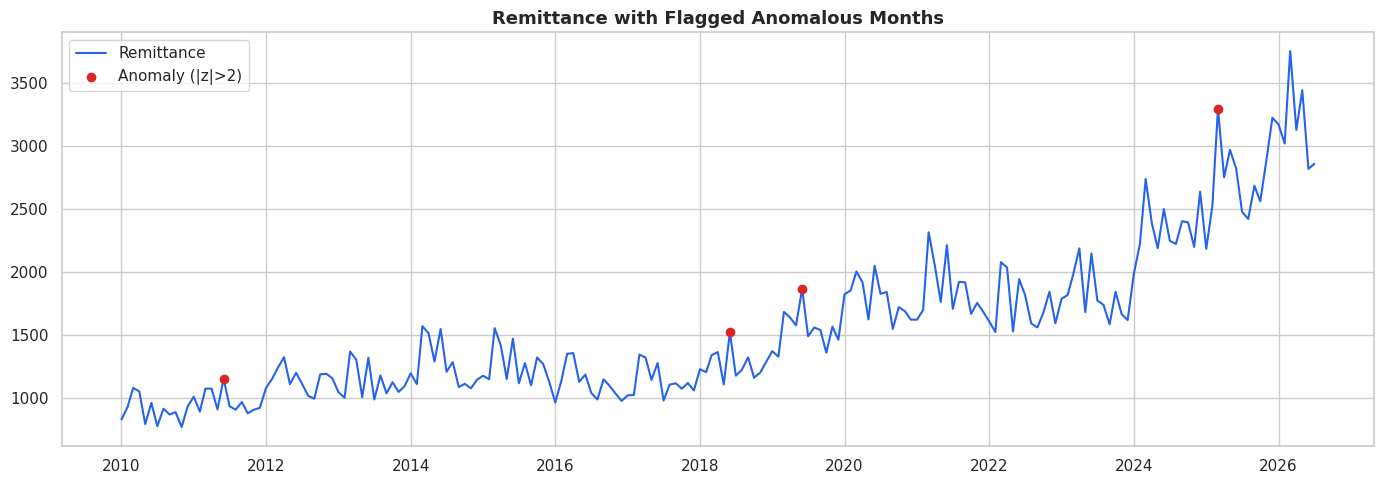

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Remittance"], color="#2563eb", label="Remittance")
plt.scatter(outliers["Date"], outliers["Remittance"], color="#dc2626", zorder=5, label="Anomaly (|z|>2)")
plt.title("Remittance with Flagged Anomalous Months")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Summary of EDA Findings

Fill in / adjust these bullets once you've reviewed the plots above — this is a template based on
typical patterns in this kind of data:

1. **Trend:** Remittance shows a long-run upward trend with a structural acceleration around
   2019–2020 (policy incentive + COVID-era hundi-channel disruption effects), and depreciation
   pressure on BDT visible from ~2022 onward.
2. **Seasonality:** Clear month-of-year spikes align with the Eid periods; since Eid drifts across
   the Gregorian calendar, a fixed "month" seasonal dummy is imperfect — consider an
   Islamic-calendar-aware Eid-proximity feature for the ML models.
3. **Stationarity:** Levels are non-stationary (as expected for macro series with trend); first
   differences / YoY % changes are closer to stationary — useful for feature engineering and for
   any econometric cross-check later.
4. **Relationships:** Exchange rate shows a positive relationship with remittance in levels (BDT
   depreciation historically coincides with higher recorded remittance, partly due to incentive
   effects); check the lag plot above to see if this relationship is contemporaneous or delayed.
   Inflation's relationship is weaker/noisier — worth testing both as a raw level and as YoY change.
5. **Data quality:** [fill in based on Section 1.5 output] — note any systematic gap between the
   standalone files and the combined macro file, and any missing months found in Section 1.6.

**Next steps (Notebook 2 — Feature Engineering & Modeling):**
- Build lag features (t-1, t-3, t-6, t-12) for all three series
- Add Eid-proximity / month dummies, rolling means/std
- Train Linear Regression (baseline) → XGBoost → LightGBM → LSTM
- Evaluate with walk-forward validation (RMSE, MAE, MAPE, directional accuracy)


## 10. Baseline Forecasting Models

With the EDA complete, we now implement four benchmark forecasting models — **Naive**, **Seasonal Naive**, **Moving Average**, and **Linear Regression** — for each of the three target series (`Remittance`, `ExchangeRate`, `Inflation`). These serve as baselines that the later ML models (XGBoost, LightGBM, LSTM) will need to beat.

We use a simple **hold-out split**: the last 12 months are reserved as the test set, and everything before that is the training set — this lines up with the 12-month seasonal cycle confirmed in the decomposition above (Section 4).

### 10.1 Imports for Modeling

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 10.2 Train/Test Split
We use the last 12 months as the test set (one full seasonal cycle).

In [ ]:
TEST_SIZE = 12
TARGETS = ["Remittance", "ExchangeRate", "Inflation"]

model_df = df[["Date"] + TARGETS].dropna().reset_index(drop=True)

train = model_df.iloc[:-TEST_SIZE]
test  = model_df.iloc[-TEST_SIZE:]

print(f"Train: {train['Date'].min().date()} to {train['Date'].max().date()}  ({len(train)} months)")
print(f"Test:  {test['Date'].min().date()} to {test['Date'].max().date()}  ({len(test)} months)")

Train: 2010-01-01 to 2025-07-01  (187 months)
Test:  2025-08-01 to 2026-07-01  (12 months)


### 10.3 Evaluation Metric Helper

In [ ]:
def evaluate(y_true, y_pred, model_name, target_name):
    """Return MAE, RMSE, MAPE for a set of predictions, aligned on index."""
    aligned = pd.concat([y_true.rename("y_true"), y_pred.rename("y_pred")], axis=1).dropna()
    mae  = mean_absolute_error(aligned["y_true"], aligned["y_pred"])
    rmse = np.sqrt(mean_squared_error(aligned["y_true"], aligned["y_pred"]))
    mape = (np.abs((aligned["y_true"] - aligned["y_pred"]) / aligned["y_true"])).mean() * 100
    return {"Target": target_name, "Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape}

### 10.4 Naive Forecast
The simplest possible baseline: predict that this month's value equals the actual value observed last month (a one-step "persistence" forecast).

In [ ]:
def naive_forecast(series, test_size):
    """y_hat(t) = y(t-1), the last observed actual value."""
    return series.shift(1).iloc[-test_size:]

### 10.5 Seasonal Naive Forecast
Given the strong 12-month seasonality confirmed in the decomposition (Section 4), a seasonal-naive forecast — this month's value equals the value from the same month last year — should outperform plain Naive, especially for `Remittance`, which is driven by the Eid cycle.

In [ ]:
def seasonal_naive_forecast(series, test_size, season=12):
    """y_hat(t) = y(t - season), the value one full seasonal cycle ago."""
    return series.shift(season).iloc[-test_size:]

### 10.6 Moving Average Forecast
Forecast each month as the average of the previous `window` actual observations (window = 3 months).

In [ ]:
def moving_average_forecast(series, test_size, window=3):
    """y_hat(t) = mean of the previous `window` actual observations."""
    return series.shift(1).rolling(window).mean().iloc[-test_size:]

### 10.7 Linear Regression Forecast
Unlike the three baselines above, Linear Regression is fit once on the training set using a **linear trend** feature (a month index `t`) plus **month-of-year dummy variables** (to capture the Eid-driven seasonality found earlier), then used to predict the entire test horizon directly.

In [ ]:
def linear_regression_forecast(model_df, target_col, test_size):
    data = model_df.copy()
    data["t"] = np.arange(len(data))
    data["month"] = data["Date"].dt.month
    month_dummies = pd.get_dummies(data["month"], prefix="m", drop_first=True)
    X = pd.concat([data[["t"]], month_dummies], axis=1)
    y = data[target_col]

    X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    y_train = y.iloc[:-test_size]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    preds = pd.Series(lr.predict(X_test), index=y.iloc[-test_size:].index)
    return preds, lr

### 10.8 Run All Models for Each Target & Compare

In [ ]:
results = []
predictions = {}  # predictions[target][model_name] -> pd.Series of forecasts

for target in TARGETS:
    series = model_df[target]
    y_test = series.iloc[-TEST_SIZE:]

    preds_naive  = naive_forecast(series, TEST_SIZE)
    preds_snaive = seasonal_naive_forecast(series, TEST_SIZE)
    preds_ma     = moving_average_forecast(series, TEST_SIZE, window=3)
    preds_lr, lr_model = linear_regression_forecast(model_df, target, TEST_SIZE)

    predictions[target] = {
        "Naive": preds_naive,
        "Seasonal Naive": preds_snaive,
        "Moving Average (3mo)": preds_ma,
        "Linear Regression": preds_lr,
    }

    for model_name, preds in predictions[target].items():
        results.append(evaluate(y_test, preds, model_name, target))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Target", "RMSE"]).reset_index(drop=True)
results_df

,Target,Model,MAE,RMSE,MAPE (%)
0,ExchangeRate,Naive,0.137500,0.190941,0.113004
1,ExchangeRate,Moving Average (3mo),0.283333,0.322820,0.232848
2,ExchangeRate,Seasonal Naive,2.000000,2.012668,1.644159
3,ExchangeRate,Linear Regression,14.193575,14.203537,11.667184
4,Inflation,Naive,0.338333,0.443546,3.744529
5,Inflation,Moving Average (3mo),0.351111,0.501780,3.903761
6,Inflation,Seasonal Naive,0.625833,0.863988,6.968676
7,Inflation,Linear Regression,2.481036,2.572092,25.655426
8,Remittance,Moving Average (3mo),293.025278,350.479453,9.669240
9,Remittance,Naive,303.697500,381.832607,9.789647


### 10.9 Best Model per Target (by RMSE)

In [ ]:
best_per_target = results_df.loc[results_df.groupby("Target")["RMSE"].idxmin()].reset_index(drop=True)
best_per_target

,Target,Model,MAE,RMSE,MAPE (%)
0,ExchangeRate,Naive,0.137500,0.190941,0.113004
1,Inflation,Naive,0.338333,0.443546,3.744529
2,Remittance,Moving Average (3mo),293.025278,350.479453,9.669240


### 10.10 Actual vs. Forecast Plots

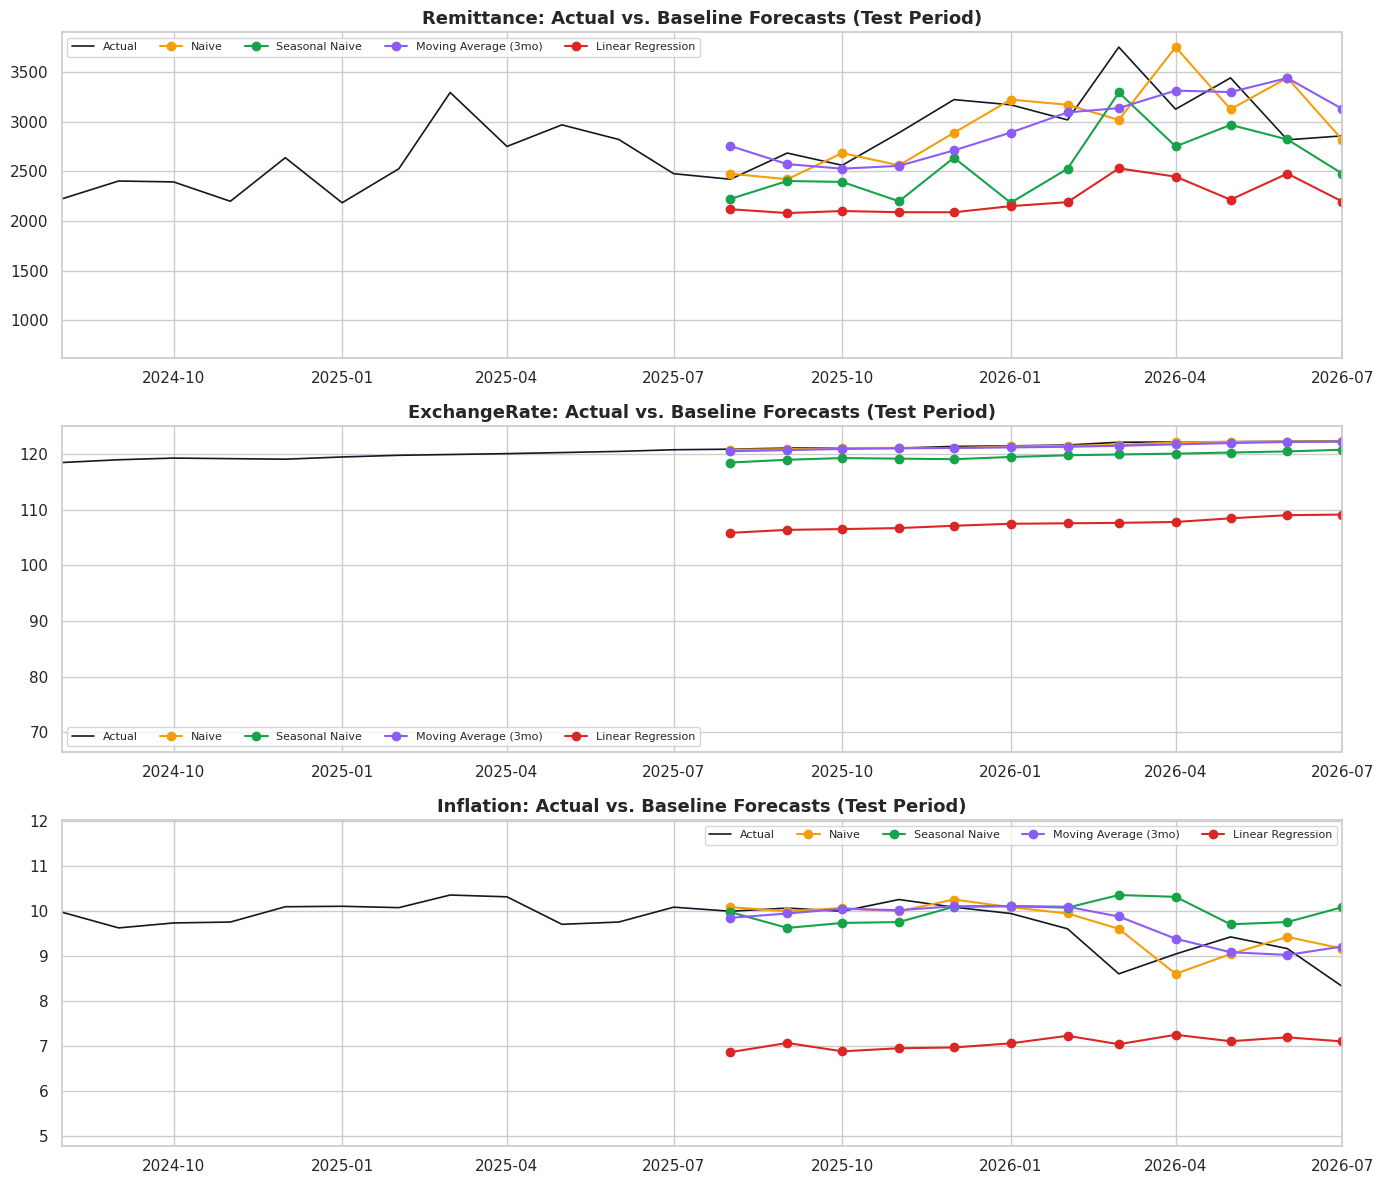

In [ ]:
colors = {"Naive": "#f59e0b", "Seasonal Naive": "#16a34a",
          "Moving Average (3mo)": "#8b5cf6", "Linear Regression": "#dc2626"}

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 12))

for ax, target in zip(axes, TARGETS):
    test_dates = model_df["Date"].iloc[-TEST_SIZE:]
    ax.plot(model_df["Date"], model_df[target], color="#111827", linewidth=1.2, label="Actual")

    for model_name, preds in predictions[target].items():
        ax.plot(test_dates, preds.values, marker="o", linewidth=1.5,
                color=colors[model_name], label=model_name)

    ax.set_xlim(model_df["Date"].iloc[max(0, len(model_df) - TEST_SIZE - 12)], model_df["Date"].iloc[-1])
    ax.set_title(f"{target}: Actual vs. Baseline Forecasts (Test Period)")
    ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()

### 10.11 Summary of Baseline Results

Fill in / adjust once you've reviewed the metrics table and plots above — this is a template based on typical patterns in this kind of data:

1. **Seasonal Naive** is expected to outperform plain **Naive** on `Remittance`, given the confirmed Eid-driven 12-month seasonality (Sections 3–4).
2. **Linear Regression** should do best on series with a strong, smooth trend (e.g. `ExchangeRate`'s steady depreciation), since the naive-style models can't extrapolate a trend.
3. **Moving Average** should sit between the two naive models on volatile-but-trending series, smoothing out short-term noise but lagging behind sharp turning points.
4. These four models set the baseline **MAE / RMSE / MAPE** that XGBoost, LightGBM, and LSTM need to beat in the next modeling notebook.

## 11. ML Model Tier — Forecasting Remittance Only

The baseline tier (Section 10) evaluated Naive / Seasonal Naive / Moving Average / Linear Regression
independently on all three series. From here on, we focus on the actual project goal:

> **Forecast Remittance using its own trend/lags, plus the effect of Exchange Rate & Inflation
> (as multivariate exogenous features).**

We now build **7 ML/DL models**, all predicting `Remittance` using a shared multivariate feature set:

1. Linear Regression (multivariate)
2. Ridge Regression
3. Random Forest
4. XGBoost
5. LightGBM
6. LSTM
7. GRU

All models are evaluated on the same held-out test period for a fair comparison.


### 11.1 Imports for ML Tier

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silence TensorFlow info/warning logs

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


### 11.2 Feature Engineering
Build a shared tabular feature set for the tree/linear models:
- Lagged values of Remittance, ExchangeRate, and Inflation (t-1, t-2, t-3, t-6, t-12)
- Rolling mean/std of Remittance (3-month, 6-month) to capture short-term momentum
- Month-of-year dummy variables to capture Eid/seasonal effects

The first 12 rows are dropped (insufficient history for the t-12 lag feature).

In [ ]:
LAGS = [1, 2, 3, 6, 12]

feat = df[["Date", "Remittance", "ExchangeRate", "Inflation"]].copy()

for lag in LAGS:
    feat[f"Remittance_lag{lag}"] = feat["Remittance"].shift(lag)
    feat[f"ExchangeRate_lag{lag}"] = feat["ExchangeRate"].shift(lag)
    feat[f"Inflation_lag{lag}"] = feat["Inflation"].shift(lag)

feat["Remittance_roll_mean3"] = feat["Remittance"].shift(1).rolling(3).mean()
feat["Remittance_roll_std3"]  = feat["Remittance"].shift(1).rolling(3).std()
feat["Remittance_roll_mean6"] = feat["Remittance"].shift(1).rolling(6).mean()

feat["month"] = feat["Date"].dt.month
month_dummies = pd.get_dummies(feat["month"], prefix="m", drop_first=True)
feat = pd.concat([feat, month_dummies], axis=1)

# Drop rows with NaN Remittance/ExchangeRate/Inflation (target availability) or insufficient lag history
feat = feat.dropna(subset=["Remittance", "ExchangeRate", "Inflation"]).reset_index(drop=True)
feat_ml = feat.dropna().reset_index(drop=True)   # drops the first 12 rows (lag warm-up period)

print("Feature-engineered rows:", feat_ml.shape[0], "| Columns:", feat_ml.shape[1])
feat_ml.head()


Feature-engineered rows: 187 | Columns: 34


,Date,Remittance,ExchangeRate,Inflation,Remittance_lag1,ExchangeRate_lag1,Inflation_lag1,Remittance_lag2,ExchangeRate_lag2,Inflation_lag2,Remittance_lag3,ExchangeRate_lag3,Inflation_lag3,Remittance_lag6,ExchangeRate_lag6,Inflation_lag6,Remittance_lag12,ExchangeRate_lag12,Inflation_lag12,Remittance_roll_mean3,Remittance_roll_std3,Remittance_roll_mean6,month,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
0,2011-01-01,1013.16,71.15,11.12,935.35,70.75,7.84,773.02,70.20,8.32,890.58,69.80,7.71,779.43,69.45,8.41,833.55,69.12,8.14,866.316667,83.840857,861.381667,1,False,False,False,False,False,False,False,False,False,False,False
1,2011-02-01,895.34,71.30,11.62,1013.16,71.15,11.12,935.35,70.75,7.84,773.02,70.20,8.32,917.62,69.50,7.76,932.07,69.25,8.03,907.176667,122.523906,900.336667,2,True,False,False,False,False,False,False,False,False,False,False
2,2011-03-01,1076.82,71.95,11.41,895.34,71.30,11.62,1013.16,71.15,11.12,935.35,70.75,7.84,872.29,69.65,8.40,1083.02,69.20,8.05,947.950000,59.912086,896.623333,3,False,True,False,False,False,False,False,False,False,False,False
3,2011-04-01,1077.18,72.40,11.68,1076.82,71.95,11.41,895.34,71.30,11.62,1013.16,71.15,11.12,890.58,69.80,7.71,1055.42,69.28,8.14,995.106667,92.077086,930.711667,4,False,False,True,False,False,False,False,False,False,False,False
4,2011-05-01,912.81,73.20,11.18,1077.18,72.40,11.68,1076.82,71.95,11.41,895.34,71.30,11.62,773.02,70.20,8.32,796.18,69.35,8.47,1016.446667,104.881604,961.811667,5,False,False,False,True,False,False,False,False,False,False,False


### 11.3 Train/Test Split (ML Tier)
Same scheme as the baseline tier: last 12 months held out as the test set.

In [ ]:
ML_TEST_SIZE = 12

feature_cols = [c for c in feat_ml.columns if c not in ["Date", "Remittance", "ExchangeRate", "Inflation", "month"]]
target_col = "Remittance"

X = feat_ml[feature_cols]
y = feat_ml[target_col]
dates_ml = feat_ml["Date"]

X_train, X_test = X.iloc[:-ML_TEST_SIZE], X.iloc[-ML_TEST_SIZE:]
y_train, y_test = y.iloc[:-ML_TEST_SIZE], y.iloc[-ML_TEST_SIZE:]
dates_train, dates_test = dates_ml.iloc[:-ML_TEST_SIZE], dates_ml.iloc[-ML_TEST_SIZE:]

print(f"Train: {dates_train.min().date()} to {dates_train.max().date()}  ({len(X_train)} months)")
print(f"Test:  {dates_test.min().date()} to {dates_test.max().date()}  ({len(X_test)} months)")
print(f"Number of features: {len(feature_cols)}")


Train: 2011-01-01 to 2025-07-01  (175 months)
Test:  2025-08-01 to 2026-07-01  (12 months)
Number of features: 29


### 11.4 Storage for ML Tier Results
Reuses the `evaluate()` helper defined in Section 10.3.

In [ ]:
ml_results = []
ml_predictions = {}   # ml_predictions[model_name] -> pd.Series indexed like y_test, aligned to dates_test


### 11.5 Model 1 — Linear Regression (Multivariate)
Unlike the univariate baseline in Section 10.7 (trend + month dummies only), this version uses the
full multivariate feature set: lagged Remittance, lagged Exchange Rate, lagged Inflation, rolling
stats, and month dummies.

In [ ]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
preds_lr_multi = pd.Series(lr_multi.predict(X_test), index=dates_test)

ml_predictions["Linear Regression (multivariate)"] = preds_lr_multi
ml_results.append(evaluate(pd.Series(y_test.values, index=dates_test),
                            preds_lr_multi, "Linear Regression (multivariate)", "Remittance"))


### 11.6 Model 2 — Ridge Regression
L2-regularized linear regression — helps guard against overfitting/multicollinearity from the many
correlated lag features.

In [ ]:
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train, y_train)
preds_ridge = pd.Series(ridge.predict(X_test), index=dates_test)

ml_predictions["Ridge Regression"] = preds_ridge
ml_results.append(evaluate(pd.Series(y_test.values, index=dates_test),
                            preds_ridge, "Ridge Regression", "Remittance"))


### 11.7 Model 3 — Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
preds_rf = pd.Series(rf.predict(X_test), index=dates_test)

ml_predictions["Random Forest"] = preds_rf
ml_results.append(evaluate(pd.Series(y_test.values, index=dates_test),
                            preds_rf, "Random Forest", "Remittance"))


### 11.8 Model 4 — XGBoost

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
preds_xgb = pd.Series(xgb.predict(X_test), index=dates_test)

ml_predictions["XGBoost"] = preds_xgb
ml_results.append(evaluate(pd.Series(y_test.values, index=dates_test),
                            preds_xgb, "XGBoost", "Remittance"))


### 11.9 Model 5 — LightGBM

In [ ]:
lgbm = LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbose=-1,
)
lgbm.fit(X_train, y_train)
preds_lgbm = pd.Series(lgbm.predict(X_test), index=dates_test)

ml_predictions["LightGBM"] = preds_lgbm
ml_results.append(evaluate(pd.Series(y_test.values, index=dates_test),
                            preds_lgbm, "LightGBM", "Remittance"))


### 11.10 Sequence Data Prep for LSTM / GRU
Deep sequence models need 3D input `(samples, timesteps, features)` rather than the flat lag-feature
table used above. We build sliding windows of the last `WINDOW` months of `[Remittance, ExchangeRate,
Inflation]` to predict the next month's Remittance, and scale everything with a `MinMaxScaler` fit
**only on the training portion** to avoid leakage.

In [ ]:
WINDOW = 12  # months of history per sample

seq_data = df[["Date", "Remittance", "ExchangeRate", "Inflation"]].dropna().reset_index(drop=True)
seq_features = ["Remittance", "ExchangeRate", "Inflation"]

# Determine the split point so the test set again covers the last 12 months
n_total = len(seq_data)
n_test = 12
split_idx = n_total - n_test

scaler = MinMaxScaler()
scaler.fit(seq_data.loc[:split_idx - 1, seq_features])  # fit on train only
scaled = scaler.transform(seq_data[seq_features])
scaled_df = pd.DataFrame(scaled, columns=seq_features)

target_idx = seq_features.index("Remittance")

def make_windows(scaled_array, window, start, end):
    """Build (X, y) windows using rows [start, end) as the *target* rows."""
    Xs, ys, idxs = [], [], []
    for t in range(start, end):
        if t - window < 0:
            continue
        Xs.append(scaled_array[t - window:t, :])
        ys.append(scaled_array[t, target_idx])
        idxs.append(t)
    return np.array(Xs), np.array(ys), idxs

scaled_array = scaled_df.values

X_seq_train, y_seq_train, idx_train = make_windows(scaled_array, WINDOW, WINDOW, split_idx)
X_seq_test,  y_seq_test,  idx_test  = make_windows(scaled_array, WINDOW, split_idx, n_total)

dates_seq_test = seq_data["Date"].iloc[idx_test].reset_index(drop=True)

print("Train sequences:", X_seq_train.shape, "| Test sequences:", X_seq_test.shape)
print("Test period:", dates_seq_test.min().date(), "to", dates_seq_test.max().date())


Train sequences: (175, 12, 3) | Test sequences: (12, 12, 3)
Test period: 2025-08-01 to 2026-07-01


Helper to inverse-transform a scaled Remittance prediction back to Million USD (since the
scaler was fit on all 3 columns jointly, we reconstruct a dummy row to inverse-transform correctly).

In [ ]:
def inverse_remittance(scaled_values):
    dummy = np.zeros((len(scaled_values), len(seq_features)))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_seq_test_actual = pd.Series(inverse_remittance(y_seq_test), index=dates_seq_test)


### 11.11 Model 6 — LSTM

In [ ]:
tf.random.set_seed(SEED)

lstm_model = Sequential([
    Input(shape=(WINDOW, len(seq_features))),
    LSTM(32, activation="tanh"),
    Dense(16, activation="relu"),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_seq_train, y_seq_train,
    epochs=150, batch_size=8,
    callbacks=[early_stop],
    verbose=0,
)

preds_lstm_scaled = lstm_model.predict(X_seq_test, verbose=0).flatten()
preds_lstm = pd.Series(inverse_remittance(preds_lstm_scaled), index=dates_seq_test)

ml_predictions["LSTM"] = preds_lstm
ml_results.append(evaluate(y_seq_test_actual, preds_lstm, "LSTM", "Remittance"))

print(f"LSTM trained for {len(history_lstm.history['loss'])} epochs (early stopping on loss).")


LSTM trained for 150 epochs (early stopping on loss).


### 11.12 Model 7 — GRU

In [ ]:
tf.random.set_seed(SEED)

gru_model = Sequential([
    Input(shape=(WINDOW, len(seq_features))),
    GRU(32, activation="tanh"),
    Dense(16, activation="relu"),
    Dense(1),
])
gru_model.compile(optimizer="adam", loss="mse")

early_stop_gru = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)

history_gru = gru_model.fit(
    X_seq_train, y_seq_train,
    epochs=150, batch_size=8,
    callbacks=[early_stop_gru],
    verbose=0,
)

preds_gru_scaled = gru_model.predict(X_seq_test, verbose=0).flatten()
preds_gru = pd.Series(inverse_remittance(preds_gru_scaled), index=dates_seq_test)

ml_predictions["GRU"] = preds_gru
ml_results.append(evaluate(y_seq_test_actual, preds_gru, "GRU", "Remittance"))

print(f"GRU trained for {len(history_gru.history['loss'])} epochs (early stopping on loss).")


GRU trained for 150 epochs (early stopping on loss).


## 12. Full Model Comparison — All 7 ML Models + Baseline Tier (Remittance)

Combine the 4 baseline models (Section 10) with the 7 ML/DL models (Section 11), all forecasting
Remittance, into a single ranked comparison table.
Note: the LSTM/GRU test window uses `WINDOW=12` months of prior history and therefore starts at the
same last-12-months period as the other models, but its *usable* test length depends on data
availability at the sequence boundary — check the printed date ranges above if row counts differ
slightly.

In [ ]:
ml_results_df = pd.DataFrame(ml_results)

baseline_remittance = results_df[results_df["Target"] == "Remittance"].copy()

full_comparison = pd.concat([baseline_remittance, ml_results_df], ignore_index=True)
full_comparison = full_comparison.sort_values("RMSE").reset_index(drop=True)
full_comparison


,Target,Model,MAE,RMSE,MAPE (%)
0,Remittance,Ridge Regression,264.890714,310.491733,8.903340
1,Remittance,GRU,242.563934,315.158192,7.732525
2,Remittance,Linear Regression (multivariate),277.051011,328.197156,9.295335
3,Remittance,Moving Average (3mo),293.025278,350.479453,9.669240
4,Remittance,Naive,303.697500,381.832607,9.789647
5,Remittance,LSTM,305.331086,386.132675,9.599510
6,Remittance,Seasonal Naive,424.021667,491.329708,13.826746
7,Remittance,XGBoost,431.036427,519.265208,13.580887
8,Remittance,Random Forest,439.289845,546.464974,13.750576
9,Remittance,LightGBM,483.693175,589.163875,15.190097


### 12.1 Best Overall Model

In [ ]:
best_overall = full_comparison.iloc[0]
print(f"Best model for Remittance forecasting: {best_overall['Model']}")
print(f"RMSE: {best_overall['RMSE']:.2f} | MAE: {best_overall['MAE']:.2f} | MAPE: {best_overall['MAPE (%)']:.2f}%")
full_comparison


Best model for Remittance forecasting: Ridge Regression
RMSE: 310.49 | MAE: 264.89 | MAPE: 8.90%


,Target,Model,MAE,RMSE,MAPE (%)
0,Remittance,Ridge Regression,264.890714,310.491733,8.903340
1,Remittance,GRU,242.563934,315.158192,7.732525
2,Remittance,Linear Regression (multivariate),277.051011,328.197156,9.295335
3,Remittance,Moving Average (3mo),293.025278,350.479453,9.669240
4,Remittance,Naive,303.697500,381.832607,9.789647
5,Remittance,LSTM,305.331086,386.132675,9.599510
6,Remittance,Seasonal Naive,424.021667,491.329708,13.826746
7,Remittance,XGBoost,431.036427,519.265208,13.580887
8,Remittance,Random Forest,439.289845,546.464974,13.750576
9,Remittance,LightGBM,483.693175,589.163875,15.190097


### 12.2 RMSE Comparison Bar Chart

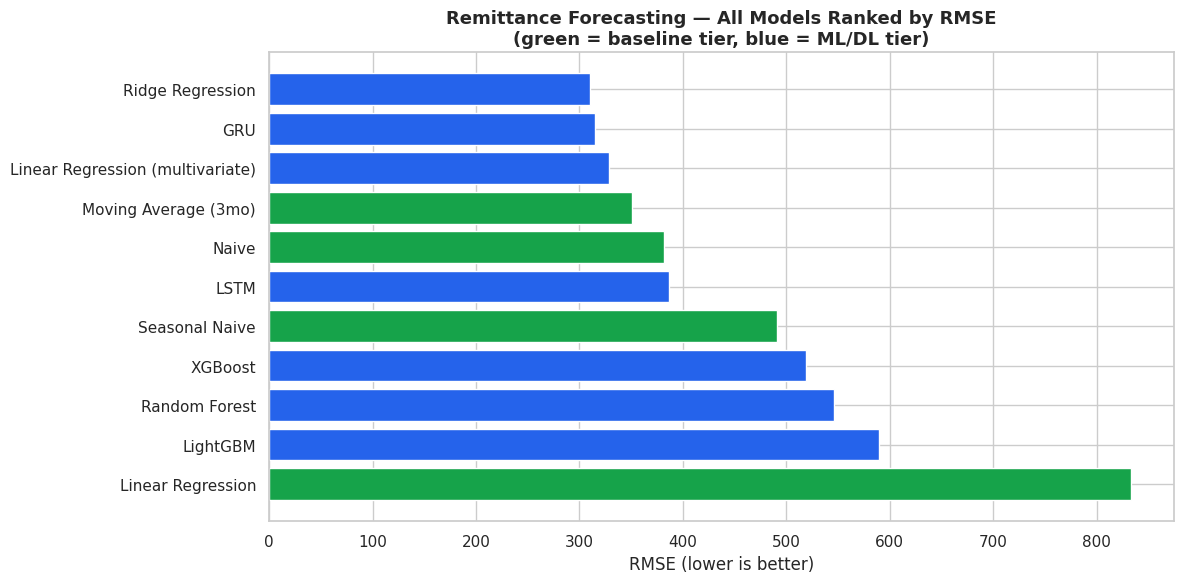

In [ ]:
plt.figure(figsize=(12, 6))
order = full_comparison.sort_values("RMSE")
colors_bar = ["#16a34a" if m in ["Naive", "Seasonal Naive", "Moving Average (3mo)", "Linear Regression"]
              else "#2563eb" for m in order["Model"]]
plt.barh(order["Model"], order["RMSE"], color=colors_bar)
plt.gca().invert_yaxis()
plt.xlabel("RMSE (lower is better)")
plt.title("Remittance Forecasting — All Models Ranked by RMSE\n(green = baseline tier, blue = ML/DL tier)")
plt.tight_layout()
plt.show()


### 12.3 Actual vs. Forecast — All 7 ML Models

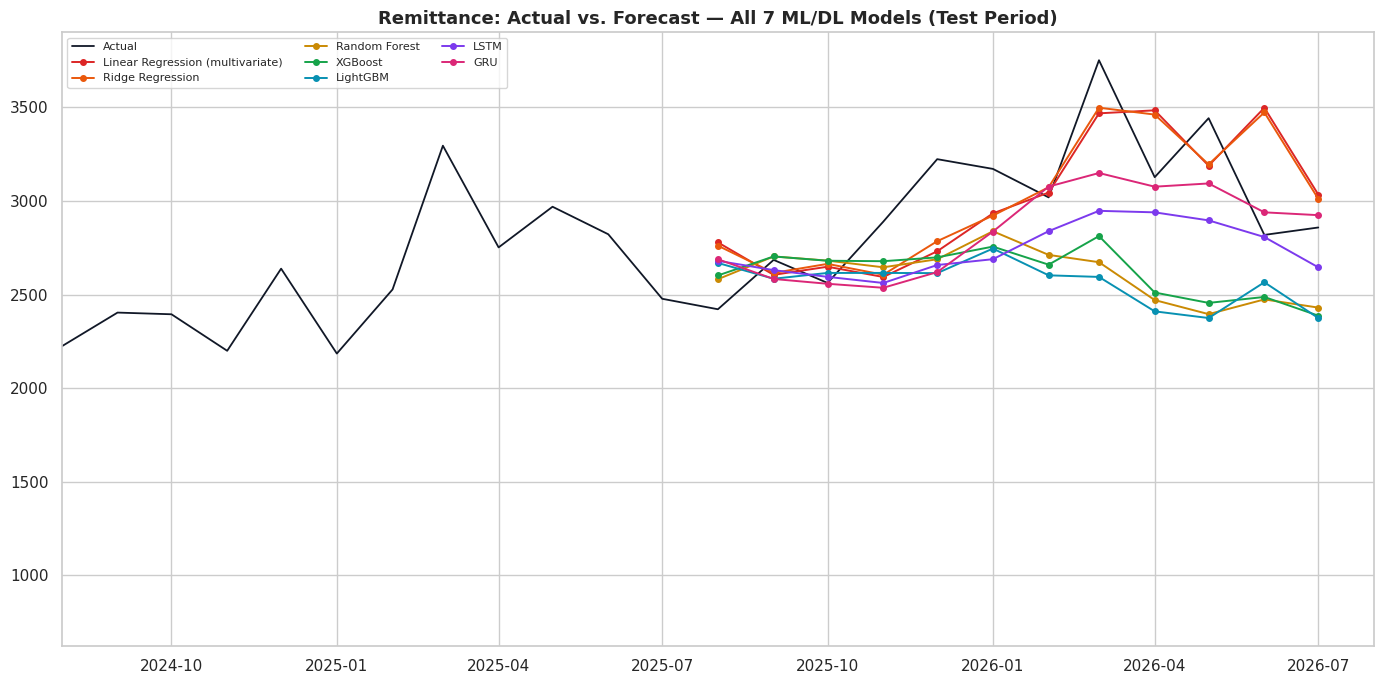

In [ ]:
plt.figure(figsize=(14, 7))

full_series_dates = df["Date"]
full_series_vals = df["Remittance"]
plt.plot(full_series_dates, full_series_vals, color="#111827", linewidth=1.3, label="Actual")

lookback_start = dates_test.iloc[0] - pd.DateOffset(months=12)
plt.xlim(lookback_start, full_series_dates.iloc[-1])

palette = ["#dc2626", "#ea580c", "#ca8a04", "#16a34a", "#0891b2", "#7c3aed", "#db2777"]
for (model_name, preds), color in zip(ml_predictions.items(), palette):
    plt.plot(preds.index, preds.values, marker="o", markersize=4, linewidth=1.4,
              color=color, label=model_name)

plt.title("Remittance: Actual vs. Forecast — All 7 ML/DL Models (Test Period)")
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


### 12.4 Feature Importance (Tree-Based Models)
Which lag/exogenous features matter most for Random Forest, XGBoost, and LightGBM?

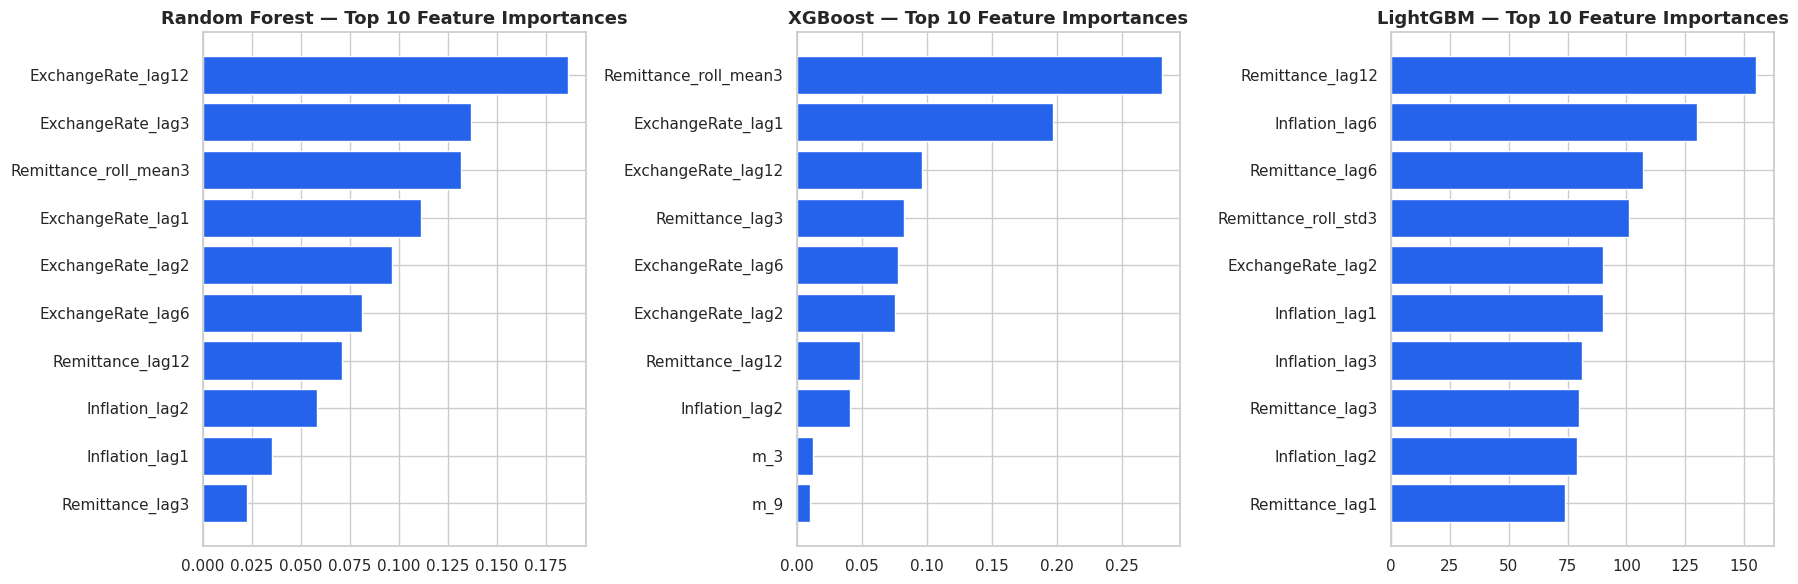

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb), ("LightGBM", lgbm)]):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
    ax.barh(importances.index[::-1], importances.values[::-1], color="#2563eb")
    ax.set_title(f"{name} — Top 10 Feature Importances")

plt.tight_layout()
plt.show()
